In [1]:
import pandas as pd
import numpy as np
from glob import glob
import matplotlib.pyplot as plt
import os, os.path as osp

In [3]:
import networkx as nx
from networkx.readwrite.graphml import read_graphml
from networkx.algorithms.shortest_paths.generic import shortest_path_length
def load_graph_stats(src='n23'):
    """Obtains the graph statistics relative to the crp gene."""
    G = read_graphml('networks/rs2.gml')
    nd_lbl_d = {}
    lbl_nd_d = {}
    for nd in G.nodes(): 
        nd_lbl_d[nd]= G.nodes[nd]['name']
        lbl_nd_d[G.nodes[nd]['name']]= nd
    shrt_paths = pd.Series(dict([(nd_lbl_d[kk],vv) for kk,vv in shortest_path_length(G,src).items()]))
    in_degrees = pd.Series(dict([(nd_lbl_d[kk],vv) for kk,vv in G.in_degree()]))
    crp_signs = pd.Series(dict([(nd_lbl_d[nd],G.edges[src,nd]['weight']) for nd in G.successors(src)]))
    auto_reg_d = {}
    for nd in G.nodes():
        try:
            auto_reg_d[nd_lbl_d[nd]]=G.edges[nd,nd]['weight']
        except KeyError:
            auto_reg_d[nd_lbl_d[nd]]=0
    auto_reg = pd.Series(auto_reg_d)
    DF = pd.concat([shrt_paths, in_degrees, crp_signs, auto_reg],axis=1)
    DF = DF.fillna({0:np.inf,1:np.nan,2:0,3:np.nan,})
    DF.columns = ['shrt_path','in_degree','src_signs','auto_reg']
    return DF,G

In [4]:
G = nx.read_gml('networks/rs2_irr_neg2_new.gml')
gstats,xG = load_graph_stats(sel_nd)

In [5]:
dat_df = pd.read_pickle('tmp/ecoli_metadata.pkl')
glu_cols = [ ('glucose' in elt.lower() or 'glu' in elt.lower()) if isinstance(elt,str) else False for elt in dat_df.Cultivation.values]
gly_cols = [ ('glycerol' in elt.lower() or 'gly' in elt.lower()) if isinstance(elt,str) else False for elt in dat_df.Cultivation.values]
sel_genos = ['cra', 'crp', 'crp,IG116', 'crp,adaptive-evolution-1', 'crp,adaptive-evolution-2',
 'crp,adaptive-evolution-3', 'crp,adaptive-evolution-4', 'crp,adaptive-evolution-5', 'crp,cyaA',
 'crp,fis', 'cusR', 'fis', 'gadE', 'gadW', 'gadX', 'hns', 'hns,hha', 'hns,stpA', 'hns,ydgT',
 'lrp', 'mazF', 'nac', 'oxyR', 'pdeL', 'pdhR', 'phoB', 'ptsG', 'rcsB', 'soxR', 'soxS',
 'stpA', 'stpa,hns', 'yiaJ', 'zraR']
gn2geno_d = {'cra':['cra'],
             'crp':['crp', 'crp,IG116', 'crp,adaptive-evolution-1', 'crp,adaptive-evolution-2', 
                    'crp,adaptive-evolution-3', 'crp,adaptive-evolution-4', 
                    'crp,adaptive-evolution-5', 'crp,cyaA', 'crp,fis'],
             'cusR':['cusR'], 'fis':['fis','crp,fis'],
             'gadE':['gadE'], 'gadW':['gadW'],
             'gadX':['gadX'], 'hns':['hns','hns,hha','hns,stpA','hns,ydgT','stpa,hns'],
             'lrp':['lrp'], 'mazF':['mazF'],
             'nac':['nac'], 'oxyR':['oxyR'],
             'pdeL':['pdeL'], 'pdhR':['pdhR'],
             'phoB':['phoB'], 'ptsG':['ptsG'],
             'rcsB':['rcsB'], 'soxR':['soxR'],
             'soxS':['soxS'], 'stpA':['stpA','hns,stpA','stpa,hns'],
             'yiaJ':['yiaJ'], 'zraR':['zraR']
            }
for gn,geno_l in gn2geno_d.items():
     break
prjna_l = dat_df[dat_df.Genotype.isin(geno_l)].Bioproject_id.value_counts().index.tolist()
dat_df[dat_df.Bioproject_id.isin(prjna_l)]

,SRR_list,Bioproject_id,SRX,GSM,Cultivation,Genotype,Sense,Dose,Treatment,Strain,GSE,Description,Path,Growth,Time,Culitvation
946,SRR1787590,PRJNA274573,SRX865357,GSM1602347,M9 0.2% glucose,NaN,"nc-kd,nc-carbon_shift",NaN,NaN,MG1655,GSE117326,Effects of cra deletion in 3 carbon sources,NaN,0.7,NaN,NaN
947,SRR1787591,PRJNA274573,SRX865358,GSM1602348,M9 0.2% glucose,NaN,"nc-kd,nc-carbon_shift",NaN,NaN,MG1655,GSE117326,Effects of cra deletion in 3 carbon sources,NaN,0.7,NaN,NaN
948,SRR1787592,PRJNA274573,SRX865359,GSM1602349,M9 0.2% fructose,NaN,"nc-kd,carbon_shift",NaN,NaN,MG1655,GSE117326,Effects of cra deletion in 3 carbon sources,NaN,0.54,NaN,NaN
949,SRR1787593,PRJNA274573,SRX865360,GSM1602350,M9 0.2% fructose,NaN,"nc-kd,carbon_shift",NaN,NaN,MG1655,GSE117326,Effects of cra deletion in 3 carbon sources,NaN,0.54,NaN,NaN
950,SRR1787594,PRJNA274573,SRX865361,GSM1602351,M9 0.2% acetate,NaN,"nc-kd,carbon_shift",NaN,NaN,MG1655,GSE117326,Effects of cra deletion in 3 carbon sources,NaN,0.32,NaN,NaN
951,SRR1787595,PRJNA274573,SRX865362,GSM1602352,M9 0.2% acetate,NaN,"nc-kd,carbon_shift",NaN,NaN,MG1655,GSE117326,Effects of cra deletion in 3 carbon sources,NaN,0.32,NaN,NaN
952,SRR1787596,PRJNA274573,SRX865363,GSM1602353,M9 0.2% glucose,cra,"kd,nc-carbon_shift",NaN,NaN,MG1655,GSE117326,Effects of cra deletion in 3 carbon sources,NaN,0.67,NaN,NaN
953,SRR1787597,PRJNA274573,SRX865364,GSM1602354,M9 0.2% glucose,cra,"kd,nc-carbon_shift",NaN,NaN,MG1655,GSE117326,Effects of cra deletion in 3 carbon sources,NaN,0.67,NaN,NaN
954,SRR1787598,PRJNA274573,SRX865365,GSM1602355,M9 0.2% fructose,cra,"kd,carbon_shift",NaN,NaN,MG1655,GSE117326,Effects of cra deletion in 3 carbon sources,NaN,0.62,NaN,NaN
955,SRR1787599,PRJNA274573,SRX865366,GSM1602356,M9 0.2% fructose,cra,"kd,carbon_shift",NaN,NaN,MG1655,GSE117326,Effects of cra deletion in 3 carbon sources,NaN,0.62,NaN,NaN


In [6]:
graph_gns = []
for nd in G.nodes():
    LBL = G.nodes[nd]['name']
    if LBL not in ['pdeL','dpiA','gutM']:
        graph_gns.append(LBL)
    else:
        if LBL=='pdeL':
            graph_gns.append('yahA')
        elif LBL=='dpiA':
            graph_gns.append('citB')
        elif LBL=='gutM':
            continue #graph_gns.append('srlR')
graph_gns = list(set(graph_gns))

In [231]:
iii=0
for (gsym,bnum),row in all_logtpm_dat.sort_index().iterrows():
    thr = row[row>0].describe().loc['25%']
    ax = row.plot(kind='hist',bins = np.linspace(0,16,161), histtype='step')
    ax.axvline(thr,ls='--',color='C7')
    ax.set_xlabel('log pseudo-TPM')
    ax.set_title(f'{gsym}')
    if not osp.exists('histograms'):
        os.mkdir('histograms')
    plt.gcf().savefig(f'histograms/{iii:02d}.png')
    plt.clf()
    iii+=1
    

<Figure size 640x480 with 0 Axes>

In [323]:
adjustments_d = {'zraR':0.45, 'rhaS':0.25, 'ptsG':0.6, 'ompR':0.1, 
                'mlrA':0.6, 'mlc':0.1, 'melR':0.4,
                'lsrR':0.3, 'lldR':0.1, 'hyfR':0.3, 'hns':0.25, 'hdfR':0.15, 'glcC':0.15,
                'gadX':0.35, 'gadW':0.6, 'gadE':0.5, 'fucR':0.15, 'flhD':0.3,
                'flhC':0.3, 'fhlA':0.15, 'csgD':0.25, 'argP':0.3, 'aidB':0.5}
gsym_bias_d = {}
gsym_biasz_d = {}
gsym_thr_d = {}
for (gsym,bnum),row in all_logtpm_dat.iterrows():
    thr = row[row>0].describe().loc['25%']
    gsym_biasz_d[gsym] = (row>0).mean()
    if gsym in adjustments_d.keys():
        thr+=adjustments_d[gsym]
    gsym_thr_d[gsym] = thr
    gsym_bias_d[gsym] = (row>thr).mean()
gsym_thr_ser = pd.Series(gsym_thr_d).sort_index()
gsym_bias_ser = pd.Series(gsym_bias_d).sort_index()
gsym_biasz_ser = pd.Series(gsym_biasz_d).sort_index()
gsym_thr_ser.to_pickle('tmp/gsym_thr_ser.pkl')
gsym_bias_ser.to_pickle('tmp/gsym_bias_ser.pkl')
gsym_biasz_ser.to_pickle('tmp/gsym_biasz_ser.pkl')

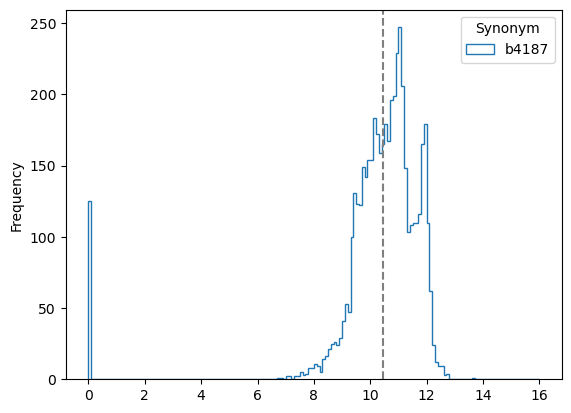

In [269]:
gsym = 'aidB'
diff = 0.5
ax = all_logtpm_dat.loc[gsym].T.plot(kind='hist',bins = np.linspace(0,16,161), histtype='step')
ax.axvline(gsym_thr_ser.loc[gsym]+diff,ls='--',color='C7')